In [1]:
import pandas as pd

In [ ]:
df_1 = pd.read_csv('일별 행정동 성별 생활인구 월별 일평균.csv')

In [3]:
import pandas as pd
import os

# 변환할 엑셀 파일 리스트
excel_files = [
    "일별 행정동 성별 생활인구 월별 일평균.xlsx",
    "일별 행정동 성별 소비매출 월별 일평균.xlsx",
    "일별 행정동 시간 생활인구 월별 일평균.xlsx",
    "일별 행정동 시간 소비매출 월별 일평균.xlsx",
    "일별 행정동 업종(대) 소비매출 월별 일평균.xlsx",
    "일별 행정동 연령 생활인구 월별 일평균.xlsx",
    "일별 행정동 연령 소비매출 월별 일평균.xlsx"
]

# 각 엑셀 파일을 CSV로 변환
for file in excel_files:
    try:
        # 엑셀 파일 읽기
        df = pd.read_excel(file)

        # CSV 파일명 생성 (확장자만 .csv로 변경)
        csv_file = os.path.splitext(file)[0] + ".csv"

        # CSV로 저장
        df.to_csv(csv_file, index=False, encoding='utf-8-sig')
        print(f"'{file}'이(가) '{csv_file}'(으)로 변환되었습니다.")
    except Exception as e:
        print(f"'{file}' 처리 중 오류 발생: {str(e)}")

print("모든 파일 변환 완료!")

'일별 행정동 성별 생활인구 월별 일평균.xlsx'이(가) '일별 행정동 성별 생활인구 월별 일평균.csv'(으)로 변환되었습니다.
'일별 행정동 성별 소비매출 월별 일평균.xlsx'이(가) '일별 행정동 성별 소비매출 월별 일평균.csv'(으)로 변환되었습니다.
'일별 행정동 시간 생활인구 월별 일평균.xlsx'이(가) '일별 행정동 시간 생활인구 월별 일평균.csv'(으)로 변환되었습니다.
'일별 행정동 시간 소비매출 월별 일평균.xlsx'이(가) '일별 행정동 시간 소비매출 월별 일평균.csv'(으)로 변환되었습니다.
'일별 행정동 업종(대) 소비매출 월별 일평균.xlsx'이(가) '일별 행정동 업종(대) 소비매출 월별 일평균.csv'(으)로 변환되었습니다.
'일별 행정동 연령 생활인구 월별 일평균.xlsx'이(가) '일별 행정동 연령 생활인구 월별 일평균.csv'(으)로 변환되었습니다.
'일별 행정동 연령 소비매출 월별 일평균.xlsx'이(가) '일별 행정동 연령 소비매출 월별 일평균.csv'(으)로 변환되었습니다.
모든 파일 변환 완료!


In [7]:
import pandas as pd

# 1. 데이터 로드
file_path = "일별 행정동 성별 생활인구 월별 일평균.csv"
try:
    gender_pop = pd.read_csv(file_path)
    print("원본 데이터 샘플:")
    print(gender_pop.head())
except Exception as e:
    print(f"파일 로드 실패: {str(e)}")
    exit()

# 2. 성별 값 변환 (남성/여성 → male/female)
gender_pop['성별'] = gender_pop['성별'].map({'남성': 'male', '여성': 'female'})

# 3. 피벗팅 실행
gender_pop_pivoted = gender_pop.pivot_table(
    index=['기준년월', '행정동코드', '행정동명'],
    columns='성별',
    values=['평균주거인구수', '평균직장인구수', '평균방문인구수'],
    aggfunc='first'
).reset_index()

# 4. 컬럼명 재구성 (멀티인덱스 해제)
gender_pop_pivoted.columns = [
    '기준년월', '행정동코드', '행정동명',  # 공통 컬럼
    '평균주거인구수_male', '평균주거인구수_female',
    '평균직장인구수_male', '평균직장인구수_female',
    '평균방문인구수_male', '평균방문인구수_female'
]

# 5. 숫자 컬럼의 쉼표 제거 및 숫자형 변환
numeric_cols = gender_pop_pivoted.columns[3:]  # 처음 3개 컬럼 제외
for col in numeric_cols:
    gender_pop_pivoted[col] = gender_pop_pivoted[col].str.replace(',', '').astype(float)

# 6. 결과 확인
print("\n피벗팅 후 데이터 샘플:")
print(gender_pop_pivoted.head())

# 7. 메인 DataFrame 저장
df_1 = gender_pop_pivoted.copy()

원본 데이터 샘플:
      기준년월       행정동코드    행정동명  성별 평균주거인구수 평균직장인구수 평균방문인구수
0  2024-12  2611051000  중구 중앙동  남성   1,154   2,324   3,655
1  2024-12  2611051000  중구 중앙동  여성   1,251   2,432   3,673
2  2024-12  2611052000  중구 동광동  남성   1,192     522     314
3  2024-12  2611052000  중구 동광동  여성   1,050     541     304
4  2024-12  2611053000  중구 대청동  남성   2,475     872     419

피벗팅 후 데이터 샘플:
      기준년월       행정동코드    행정동명  평균주거인구수_male  평균주거인구수_female  평균직장인구수_male  \
0  2019-01  2611051000  중구 중앙동        3441.0          3768.0        1117.0   
1  2019-01  2611052000  중구 동광동         290.0           349.0         901.0   
2  2019-01  2611053000  중구 대청동         606.0           425.0        2718.0   
3  2019-01  2611054500  중구 보수동         251.0           398.0        4012.0   
4  2019-01  2611056000  중구 부평동         647.0           696.0        1928.0   

   평균직장인구수_female  평균방문인구수_male  평균방문인구수_female  
0          1238.0        2177.0          2105.0  
1          1071.0         418.0           422.0  
2

In [9]:
import pandas as pd

# 1. 데이터 로드
file_path = "일별 행정동 성별 소비매출 월별 일평균.csv"
try:
    time_pop = pd.read_csv(file_path)
    print("원본 데이터 샘플:")
    print(time_pop.head())
except Exception as e:
    print(f"파일 로드 실패: {str(e)}")
    exit()

# 2. 성별 값 변환 (남성/여성 → male/female)
time_pop['성별'] = time_pop['성별'].map({'남성': 'male', '여성': 'female'})

# 3. 피벗팅 실행
time_pop_pivoted = time_pop.pivot_table(
    index=['기준년월', '행정동코드', '행정동명'],
    columns='성별',
    values=['평균이용금액', '평균이용건수'],
    aggfunc='first'
).reset_index()

# 4. 컬럼명 재구성 (멀티인덱스 해제)
time_pop_pivoted.columns = [
    '기준년월', '행정동코드', '행정동명',  # 공통 컬럼
    '평균이용금액_male', '평균이용금액_female',
    '평균이용건수_male', '평균이용건수_female'
]

# 5. 숫자 컬럼의 쉼표 제거 및 숫자형 변환 (필요시)
numeric_cols = time_pop_pivoted.columns[3:]  # 처음 3개 컬럼 제외
for col in numeric_cols:
    if time_pop_pivoted[col].dtype == 'object':
        time_pop_pivoted[col] = time_pop_pivoted[col].str.replace(',', '').astype(float)

# 6. 결과 확인
print("\n피벗팅 후 데이터 샘플:")
print(time_pop_pivoted.head())

# 7. 별도 DataFrame 저장
df_2 = time_pop_pivoted.copy()

원본 데이터 샘플:
      기준년월       행정동코드    행정동명  성별       평균이용금액 평균이용건수
0  2024-12  2611051000  중구 중앙동  남성  287,832,000  8,920
1  2024-12  2611051000  중구 중앙동  여성  306,363,000  8,416
2  2024-12  2611052000  중구 동광동  남성   23,694,000    947
3  2024-12  2611052000  중구 동광동  여성   18,441,000    655
4  2024-12  2611053000  중구 대청동  남성   55,561,000  1,852

피벗팅 후 데이터 샘플:
      기준년월       행정동코드    행정동명  평균이용금액_male  평균이용금액_female  평균이용건수_male  \
0  2019-01  2611051000  중구 중앙동       8750.0         8509.0  330990000.0   
1  2019-01  2611052000  중구 동광동        704.0         1055.0   17246000.0   
2  2019-01  2611053000  중구 대청동       1400.0         1473.0   48141000.0   
3  2019-01  2611054500  중구 보수동        775.0         1084.0   17252000.0   
4  2019-01  2611056000  중구 부평동       4068.0         5133.0  125338000.0   

   평균이용건수_female  
0    308946000.0  
1     29105000.0  
2     39957000.0  
3     23212000.0  
4    160300000.0  


In [11]:
import pandas as pd

# 1. 데이터 로드
file_path = "일별 행정동 시간 생활인구 월별 일평균.csv"
try:
    time_pop = pd.read_csv(file_path)
    print("원본 데이터 샘플:")
    print(time_pop.head())
except Exception as e:
    print(f"파일 로드 실패: {str(e)}")
    exit()

# 2. 시간대 포맷 통일 (예: '00시' → '00')
time_pop['시간대'] = time_pop['시간대'].str.replace('시', '').str.zfill(2)

# 3. 피벗팅 실행 (시간대를 컬럼으로 확장)
time_pop_pivoted = time_pop.melt(
    id_vars=['기준년월', '행정동코드', '행정동명', '시간대'],
    value_vars=['평균주거인구수', '평균직장인구수', '평균방문인구수'],
    var_name='인구유형',
    value_name='인구수'
).pivot_table(
    index=['기준년월', '행정동코드', '행정동명'],
    columns=['인구유형', '시간대'],
    values='인구수',
    aggfunc='first'
).reset_index()

# 4. 컬럼명 재구성 (멀티인덱스 해제)
time_pop_pivoted.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0]
    for col in time_pop_pivoted.columns
]
time_pop_pivoted.columns = [
    col.replace('평균주거인구수', '주거인구')
      .replace('평균직장인구수', '직장인구')
      .replace('평균방문인구수', '방문인구')
    for col in time_pop_pivoted.columns
]

# 5. 숫자 데이터 정제 (천 단위 쉼표 제거)
for col in time_pop_pivoted.columns[3:]:
    if time_pop_pivoted[col].dtype == 'object':
        time_pop_pivoted[col] = time_pop_pivoted[col].str.replace(',', '').astype(float)

# 6. 결과 확인
print("\n피벗팅 후 데이터 구조:")
print(f"컬럼 수: {len(time_pop_pivoted.columns)}, 행 수: {len(time_pop_pivoted)}")
print("샘플 컬럼명:", time_pop_pivoted.columns[:10])

# 7. 최종 저장
df_3 = time_pop_pivoted.copy()

원본 데이터 샘플:
      기준년월       행정동코드    행정동명  시간대 평균주거인구수 평균직장인구수 평균방문인구수
0  2024-12  2611051000  중구 중앙동  00시   2,818   1,735     322
1  2024-12  2611051000  중구 중앙동  01시   2,875   1,524     261
2  2024-12  2611051000  중구 중앙동  02시   2,920   1,365     232
3  2024-12  2611051000  중구 중앙동  03시   2,956   1,277     222
4  2024-12  2611051000  중구 중앙동  04시   2,965   1,229     220

피벗팅 후 데이터 구조:
컬럼 수: 75, 행 수: 14748
샘플 컬럼명: Index(['기준년월', '행정동코드', '행정동명', '방문인구_00', '방문인구_01', '방문인구_02', '방문인구_03',
       '방문인구_04', '방문인구_05', '방문인구_06'],
      dtype='object')


In [12]:
import pandas as pd

# 1. 데이터 로드
file_path = "일별 행정동 시간 소비매출 월별 일평균.csv"
try:
    time_sales = pd.read_csv(file_path)
    print("원본 데이터 샘플:")
    print(time_sales.head())
except Exception as e:
    print(f"파일 로드 실패: {str(e)}")
    exit()

# 2. 시간대 포맷 통일 (예: '00시' → '00')
time_sales['시간대'] = time_sales['시간대'].str.replace('시', '').str.zfill(2)

# 3. 피벗팅 실행 (시간대를 컬럼으로 확장)
time_sales_pivoted = time_sales.melt(
    id_vars=['기준년월', '행정동코드', '행정동명', '시간대'],
    value_vars=['평균이용금액', '평균이용건수'],
    var_name='소비지표',
    value_name='값'
).pivot_table(
    index=['기준년월', '행정동코드', '행정동명'],
    columns=['소비지표', '시간대'],
    values='값',
    aggfunc='first'
).reset_index()

# 4. 컬럼명 재구성 (멀티인덱스 해제)
time_sales_pivoted.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0]
    for col in time_sales_pivoted.columns
]
time_sales_pivoted.columns = [
    col.replace('평균이용금액', '이용금액')
      .replace('평균이용건수', '이용건수')
    for col in time_sales_pivoted.columns
]

# 5. 숫자 데이터 정제 (천 단위 쉼표 제거)
for col in time_sales_pivoted.columns[3:]:
    if time_sales_pivoted[col].dtype == 'object':
        time_sales_pivoted[col] = time_sales_pivoted[col].str.replace(',', '').astype(float)

# 6. 결과 확인
print("\n피벗팅 후 데이터 구조:")
print(f"컬럼 수: {len(time_sales_pivoted.columns)}, 행 수: {len(time_sales_pivoted)}")
print("샘플 컬럼명:", time_sales_pivoted.columns[:10])

# 7. 최종 저장
df_4 = time_sales_pivoted.copy()

원본 데이터 샘플:
      기준년월       행정동코드    행정동명  시간대     평균이용금액 평균이용건수
0  2024-12  2611051000  중구 중앙동  00시  1,588,985     74
1  2024-12  2611051000  중구 중앙동  01시    779,062     37
2  2024-12  2611051000  중구 중앙동  02시    558,770     30
3  2024-12  2611051000  중구 중앙동  03시    352,055     24
4  2024-12  2611051000  중구 중앙동  04시    333,658     29

피벗팅 후 데이터 구조:
컬럼 수: 51, 행 수: 14760
샘플 컬럼명: Index(['기준년월', '행정동코드', '행정동명', '이용건수_00', '이용건수_01', '이용건수_02', '이용건수_03',
       '이용건수_04', '이용건수_05', '이용건수_06'],
      dtype='object')


In [13]:
import pandas as pd

# 1. 데이터 로드
file_path = "일별 행정동 업종(대) 소비매출 월별 일평균.csv"
try:
    industry_sales = pd.read_csv(file_path)
    print("원본 데이터 샘플:")
    print(industry_sales.head())
except Exception as e:
    print(f"파일 로드 실패: {str(e)}")
    exit()

# 2. 피벗팅 실행 (업종대분류를 컬럼으로 확장)
industry_sales_pivoted = industry_sales.melt(
    id_vars=['기준년월', '행정동코드', '행정동명', '업종대분류'],
    value_vars=['평균이용금액', '평균이용건수'],
    var_name='소비지표',
    value_name='값'
).pivot_table(
    index=['기준년월', '행정동코드', '행정동명'],
    columns=['업종대분류', '소비지표'],
    values='값',
    aggfunc='first'
).reset_index()

# 3. 컬럼명 재구성 (멀티인덱스 해제)
industry_sales_pivoted.columns = [
    f"{col[1]}_{col[0]}" if col[0] != '' else col[1]
    for col in industry_sales_pivoted.columns
]
industry_sales_pivoted.columns = [
    col.replace('평균이용금액_', '금액_')
      .replace('평균이용건수_', '건수_')
    for col in industry_sales_pivoted.columns
]

# 4. 숫자 데이터 정제 (천 단위 쉼표 제거)
for col in industry_sales_pivoted.columns[3:]:
    if industry_sales_pivoted[col].dtype == 'object':
        industry_sales_pivoted[col] = industry_sales_pivoted[col].str.replace(',', '').astype(float)

# 5. 결과 확인
print("\n피벗팅 후 데이터 구조:")
print(f"컬럼 수: {len(industry_sales_pivoted.columns)}, 행 수: {len(industry_sales_pivoted)}")
print("샘플 컬럼명:", industry_sales_pivoted.columns[:10])

# 6. 최종 저장
df_5 = industry_sales_pivoted.copy()

원본 데이터 샘플:
      기준년월       행정동코드    행정동명    업종대분류       평균이용금액  평균이용건수
0  2024-12  2611051000  중구 중앙동     가전가구  100,151,114     290
1  2024-12  2611051000  중구 중앙동  가정생활서비스  330,510,092  21,486
2  2024-12  2611051000  중구 중앙동     교육학원   38,995,702     257
3  2024-12  2611051000  중구 중앙동       미용   85,241,796     735
4  2024-12  2611051000  중구 중앙동  스포츠문화레저  337,201,750   7,602

피벗팅 후 데이터 구조:
컬럼 수: 31, 행 수: 14760
샘플 컬럼명: Index(['_기준년월', '_행정동코드', '_행정동명', '건수_가전가구', '금액_가전가구', '건수_가정생활서비스',
       '금액_가정생활서비스', '건수_교육학원', '금액_교육학원', '건수_미용'],
      dtype='object')


In [15]:
import pandas as pd

# 1. 데이터 로드
file_path = "일별 행정동 연령 생활인구 월별 일평균.csv"
try:
    age_pop = pd.read_csv(file_path)
    print("원본 데이터 샘플:")
    print(age_pop.head())
except Exception as e:
    print(f"파일 로드 실패: {str(e)}")
    exit()

# 2. 나이대 값 정규화 (기존 값 유지)
age_pop['나이대'] = age_pop['나이대'].str.strip()

# 3. 피벗팅 실행 (나이대를 컬럼으로 확장)
age_pop_pivoted = age_pop.melt(
    id_vars=['기준년월', '행정동코드', '행정동명', '나이대'],
    value_vars=['평균주거인구수', '평균직장인구수', '평균방문인구수'],
    var_name='인구유형',
    value_name='인구수'
).pivot_table(
    index=['기준년월', '행정동코드', '행정동명'],
    columns=['나이대', '인구유형'],
    values='인구수',
    aggfunc='first'
).reset_index()

# 4. 컬럼명 재구성 (멀티인덱스 해제)
age_pop_pivoted.columns = [
    f"{col[1]}_{col[0]}" if col[0] != '' else col[1]
    for col in age_pop_pivoted.columns
]
age_pop_pivoted.columns = [
    col.replace('평균주거인구수_', '주거_')
      .replace('평균직장인구수_', '직장_')
      .replace('평균방문인구수_', '방문_')
      .replace('20대미만', 'under20')
      .replace('20대', '20s')
      .replace('30대', '30s')
      .replace('40대', '40s')
      .replace('50대', '50s')
      .replace('60대', '60s')
      .replace('70대이상', 'over70')
    for col in age_pop_pivoted.columns
]

# 5. 숫자 데이터 정제 (천 단위 쉼표 제거)
for col in age_pop_pivoted.columns[3:]:
    if age_pop_pivoted[col].dtype == 'object':
        age_pop_pivoted[col] = age_pop_pivoted[col].str.replace(',', '').astype(float)

# 6. 결과 확인
print("\n피벗팅 후 데이터 구조:")
print(f"컬럼 수: {len(age_pop_pivoted.columns)}, 행 수: {len(age_pop_pivoted)}")
print("샘플 컬럼명:", age_pop_pivoted.columns[:10])

# 7. 최종 저장
df_6 = age_pop_pivoted.copy()

원본 데이터 샘플:
      기준년월       행정동코드    행정동명    나이대 평균주거인구수 평균직장인구수 평균방문인구수
0  2024-12  2611051000  중구 중앙동    20대     439     772   1,229
1  2024-12  2611051000  중구 중앙동  20대미만      70     415      96
2  2024-12  2611051000  중구 중앙동    30대     451     805   1,681
3  2024-12  2611051000  중구 중앙동    40대     318     892   1,824
4  2024-12  2611051000  중구 중앙동    50대     344     879   1,578

피벗팅 후 데이터 구조:
컬럼 수: 24, 행 수: 14748
샘플 컬럼명: Index(['_기준년월', '_행정동코드', '_행정동명', '방문_20s', '주거_20s', '직장_20s', '방문_under20',
       '주거_under20', '직장_under20', '방문_30s'],
      dtype='object')


In [17]:
import pandas as pd

# 1. 데이터 로드
file_path = "일별 행정동 연령 소비매출 월별 일평균.csv"
try:
    age_sales = pd.read_csv(file_path)
    print("원본 데이터 샘플:")
    print(age_sales.head())
except Exception as e:
    print(f"파일 로드 실패: {str(e)}")
    exit()

# 2. 연령대 값 정규화 (공백 제거 및 영어 변환)
age_map = {
    '20대미만': 'under20',
    '20대': '20s',
    '30대': '30s',
    '40대': '40s',
    '50대': '50s',
    '60대': '60s',
    '70대이상': 'over70'
}
age_sales['연령대'] = age_sales['연령대'].str.strip().map(age_map)

# 3. 피벗팅 실행
age_sales_pivoted = pd.pivot_table(
    age_sales,
    index=['기준년월', '행정동코드', '행정동명'],
    columns='연령대',
    values=['평균이용금액', '평균이용건수'],
    aggfunc='first'
).reset_index()

# 4. 컬럼명 재구성
age_sales_pivoted.columns = [
    f"{col[0]}_{col[1]}" if col[1] != '' else col[0]
    for col in age_sales_pivoted.columns
]

# 5. 숫자 데이터 정제
for col in age_sales_pivoted.columns[3:]:
    if age_sales_pivoted[col].dtype == 'object':
        age_sales_pivoted[col] = age_sales_pivoted[col].str.replace(',', '').astype(float)

# 6. 컬럼명 간소화
age_sales_pivoted.columns = [
    col.replace('평균이용금액_', 'amt_')
      .replace('평균이용건수_', 'cnt_')
    for col in age_sales_pivoted.columns
]

# 7. 컬럼 순서 정렬
base_cols = ['기준년월', '행정동코드', '행정동명']
age_groups = ['under20', '20s', '30s', '40s', '50s', '60s', 'over70']
new_cols = base_cols + [f"amt_{age}" for age in age_groups] + [f"cnt_{age}" for age in age_groups]
age_sales_pivoted = age_sales_pivoted[new_cols]

# 8. 결과 확인
print("\n피벗팅 후 데이터 구조:")
print(f"컬럼 수: {len(age_sales_pivoted.columns)}, 행 수: {len(age_sales_pivoted)}")
print("샘플 데이터:")
print(age_sales_pivoted.head())

# 9. 최종 저장
df_7 = age_sales_pivoted.copy()

원본 데이터 샘플:
      기준년월       행정동코드    행정동명    연령대       평균이용금액 평균이용건수
0  2024-12  2611051000  중구 중앙동    20대   62,005,386  2,478
1  2024-12  2611051000  중구 중앙동  20대미만    1,493,584     77
2  2024-12  2611051000  중구 중앙동    30대  142,154,004  5,051
3  2024-12  2611051000  중구 중앙동    40대  160,197,345  4,406
4  2024-12  2611051000  중구 중앙동    50대  129,472,167  3,032

피벗팅 후 데이터 구조:
컬럼 수: 17, 행 수: 14760
샘플 데이터:
      기준년월       행정동코드    행정동명  amt_under20     amt_20s      amt_30s  \
0  2019-01  2611051000  중구 중앙동    1216830.0  85532324.0  172633928.0   
1  2019-01  2611052000  중구 동광동     155441.0   5848755.0    9718925.0   
2  2019-01  2611053000  중구 대청동     157435.0   9320992.0   14136160.0   
3  2019-01  2611054500  중구 보수동     118713.0   4701090.0    7629234.0   
4  2019-01  2611056000  중구 부평동    1718832.0  53303294.0   56312981.0   

       amt_40s      amt_50s     amt_60s  amt_over70  cnt_under20  cnt_20s  \
0  174206806.0  125262431.0  63601632.0  17482364.0         65.0   3917.0   
1   103368

In [18]:
import pandas as pd

# 1. 기준이 될 첫 번째 데이터프레임 설정 (df_1)
df = df_1.copy()

# 2. 병합할 데이터프레임 리스트 (df_2부터 df_7까지)
dfs_to_merge = [df_2, df_3, df_4, df_5, df_6, df_7]

# 3. 순차적 병합 실행
for idx, df_temp in enumerate(dfs_to_merge, start=2):
    try:
        df = pd.merge(
            df,
            df_temp,
            on=['기준년월', '행정동코드', '행정동명'],
            how='left',
            validate='one_to_one'  # 일대일 관계 확인
        )
        print(f"df_{idx} 병합 완료 | 현재 컬럼 수: {len(df.columns)}")
    except Exception as e:
        print(f"df_{idx} 병합 실패: {str(e)}")

# 4. 병합 결과 검증
print("\n최종 데이터프레임 정보:")
print(f"총 컬럼 수: {len(df.columns)}")
print(f"총 행 수: {len(df)}")
print("\n처음 3개 컬럼 확인:")
print(df[['기준년월', '행정동코드', '행정동명']].head())
print("\n새로 추가된 컬럼 샘플:")
print(df.columns[3:10])  # 4번째부터 10개 컬럼 출력

# 5. 중복 컬럼 검사 (선택사항)
duplicate_cols = df.columns[df.columns.duplicated()]
if len(duplicate_cols) > 0:
    print("\n경고: 중복 컬럼 존재 -> ", duplicate_cols)
else:
    print("\n중복 컬럼 없음")

# 6. 최종 저장 (선택사항)
df.to_csv('통합_행정동_데이터_최종.csv', index=False, encoding='utf-8-sig')
print("\n최종 데이터가 '통합_행정동_데이터_최종.csv'로 저장되었습니다.")

df_2 병합 완료 | 현재 컬럼 수: 13
df_3 병합 완료 | 현재 컬럼 수: 85
df_4 병합 완료 | 현재 컬럼 수: 133
df_5 병합 실패: '기준년월'
df_6 병합 실패: '기준년월'
df_7 병합 완료 | 현재 컬럼 수: 147

최종 데이터프레임 정보:
총 컬럼 수: 147
총 행 수: 14748

처음 3개 컬럼 확인:
      기준년월       행정동코드    행정동명
0  2019-01  2611051000  중구 중앙동
1  2019-01  2611052000  중구 동광동
2  2019-01  2611053000  중구 대청동
3  2019-01  2611054500  중구 보수동
4  2019-01  2611056000  중구 부평동

새로 추가된 컬럼 샘플:
Index(['평균주거인구수_male', '평균주거인구수_female', '평균직장인구수_male', '평균직장인구수_female',
       '평균방문인구수_male', '평균방문인구수_female', '평균이용금액_male'],
      dtype='object')

중복 컬럼 없음

최종 데이터가 '통합_행정동_데이터_최종.csv'로 저장되었습니다.


In [19]:
df

,기준년월,행정동코드,행정동명,평균주거인구수_male,평균주거인구수_female,평균직장인구수_male,평균직장인구수_female,평균방문인구수_male,평균방문인구수_female,평균이용금액_male,...,amt_50s,amt_60s,amt_over70,cnt_under20,cnt_20s,cnt_30s,cnt_40s,cnt_50s,cnt_60s,cnt_over70
0,2019-01,2611051000,중구 중앙동,3441.0,3768.0,1117.0,1238.0,2177.0,2105.0,8750.0,...,125262431.0,63601632.0,17482364.0,65.0,3917.0,5295.0,3955.0,2560.0,1117.0,348.0
1,2019-01,2611052000,중구 동광동,290.0,349.0,901.0,1071.0,418.0,422.0,704.0,...,11344295.0,5719200.0,3248488.0,15.0,431.0,423.0,372.0,297.0,154.0,67.0
2,2019-01,2611053000,중구 대청동,606.0,425.0,2718.0,2307.0,976.0,789.0,1400.0,...,21575668.0,15928356.0,7615769.0,16.0,515.0,638.0,690.0,538.0,337.0,139.0
3,2019-01,2611054500,중구 보수동,251.0,398.0,4012.0,3514.0,591.0,644.0,775.0,...,9419219.0,5028688.0,2150071.0,16.0,462.0,400.0,444.0,317.0,167.0,52.0
4,2019-01,2611056000,중구 부평동,647.0,696.0,1928.0,1746.0,1824.0,2060.0,4068.0,...,61840435.0,36694405.0,11388839.0,105.0,2441.0,1882.0,2013.0,1641.0,841.0,275.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14743,2024-12,2671025000,기장군 기장읍,2378.0,2886.0,23181.0,20043.0,7411.0,6859.0,19218.0,...,559852031.0,307139749.0,85840305.0,233.0,4398.0,11473.0,12510.0,9741.0,5545.0,1948.0
14744,2024-12,2671025300,기장군 장안읍,1473.0,3347.0,3630.0,3659.0,2071.0,2675.0,5958.0,...,270849282.0,118140539.0,28837457.0,36.0,1256.0,4451.0,5040.0,3431.0,1707.0,493.0
14745,2024-12,2671025600,기장군 정관읍,1879.0,3280.0,33388.0,29257.0,2058.0,2709.0,13800.0,...,209759825.0,96495441.0,37178887.0,409.0,2288.0,7265.0,12773.0,6610.0,2795.0,1219.0
14746,2024-12,2671025900,기장군 일광읍,902.0,925.0,10796.0,9043.0,2553.0,2991.0,6590.0,...,143621883.0,88880926.0,28240832.0,59.0,1397.0,4466.0,4833.0,3545.0,1967.0,672.0


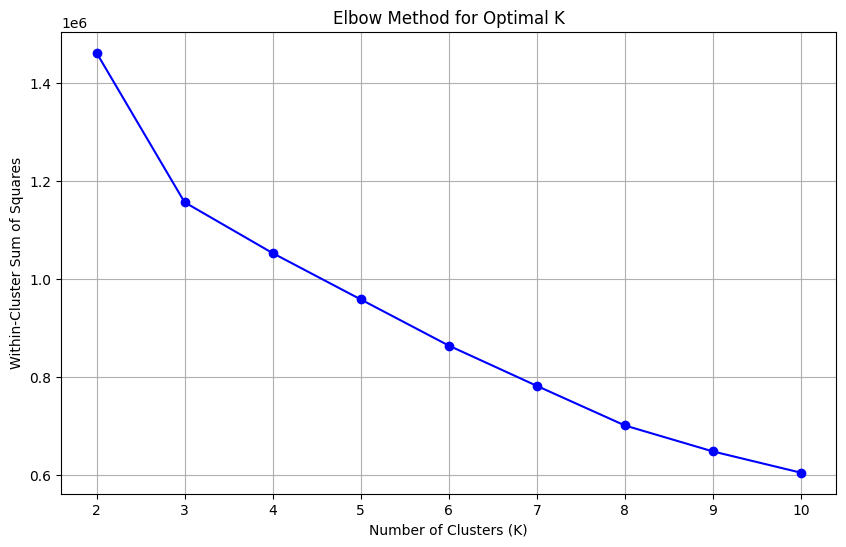

For K=2, Silhouette Score: 0.6964
For K=3, Silhouette Score: 0.3988
For K=4, Silhouette Score: 0.3318
For K=5, Silhouette Score: 0.3630
For K=6, Silhouette Score: 0.3660
For K=7, Silhouette Score: 0.3255
For K=8, Silhouette Score: 0.3342
For K=9, Silhouette Score: 0.3310
For K=10, Silhouette Score: 0.3341


<ipython-input-20-f6f7de2c576d>:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Cluster'] = kmeans.fit_predict(scaled_data)
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) D

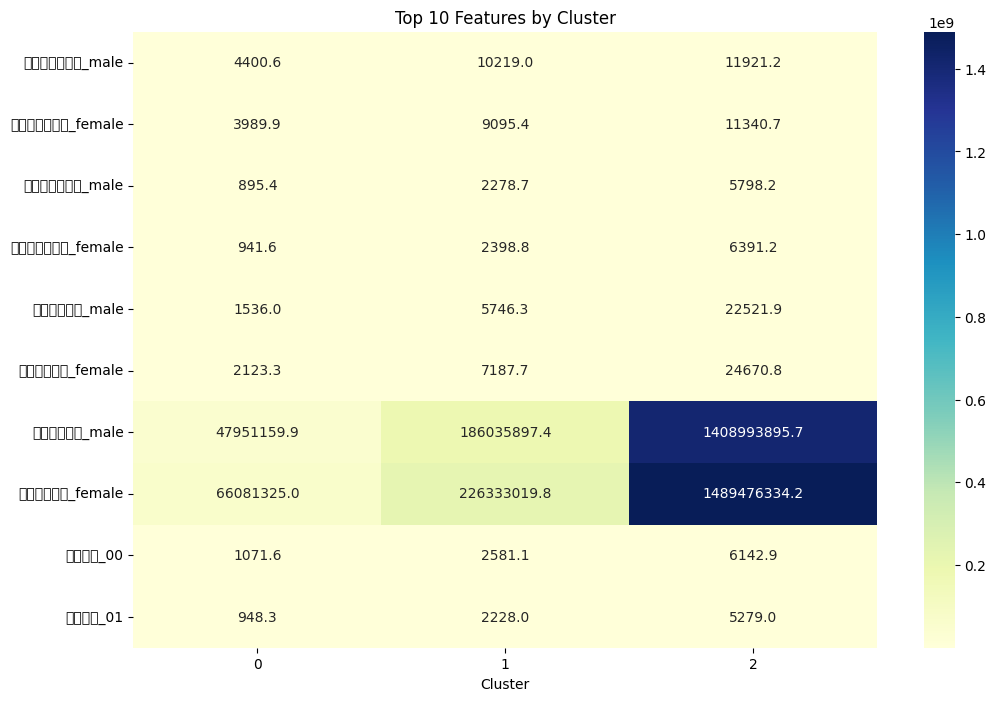

<ipython-input-20-f6f7de2c576d>:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['PCA1'] = pca_result[:, 0]
<ipython-input-20-f6f7de2c576d>:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['PCA2'] = pca_result[:, 1]


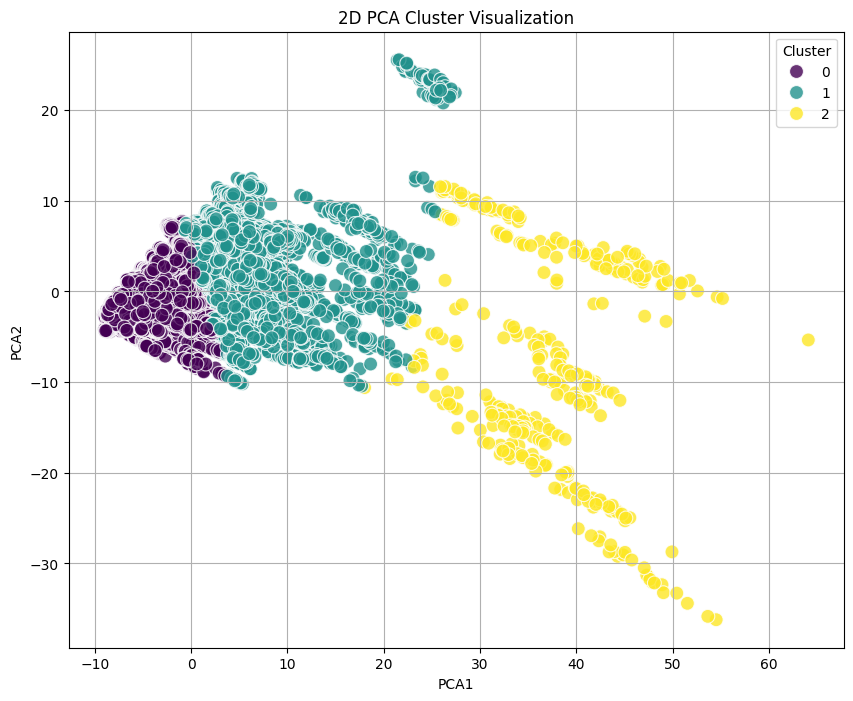


클러스터별 데이터 분포:
Cluster
0    9881
1    4493
2     374
Name: count, dtype: int64

클러스터별 주요 특성 평균:
         평균직장인구수_male  평균직장인구수_female  평균방문인구수_male  평균방문인구수_female  \
Cluster                                                               
0         4400.603077     3989.891307    895.439024      941.636272   
1        10218.998442     9095.413977   2278.741153     2398.825284   
2        11921.171123    11340.719251   5798.157754     6391.240642   

          평균이용금액_male  
Cluster                
0         1536.010323  
1         5746.329401  
2        22521.943850  


In [20]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 전처리
# ---------------------------------
# 숫자형 컬럼만 선택 (기준 컬럼 제외, 첫 3개 열 제외)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()[3:]  # 첫 3개 열 제외

# 결측값 처리 (평균값으로 대체)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 데이터 표준화
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

# 2. 최적의 K 값 찾기 (엘보우 방법)
# ---------------------------------
wcss = []  # Within-Cluster-Sum-of-Squares
k_range = range(2, 11)  # 2~10까지 테스트

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# 엘보우 차트 시각화
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid()
plt.show()

# 3. 실루엣 점수 계산
# ---------------------------------
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For K={k}, Silhouette Score: {silhouette_avg:.4f}")

# 4. 최종 클러스터링 실행 (K=3 가정)
# ---------------------------------
optimal_k = 3  # 실루엣 점수와 엘보우 차트를 보고 결정
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# 5. 클러스터 특성 분석
# ---------------------------------
# 클러스터별 평균값 계산
cluster_profile = df.groupby('Cluster')[numeric_cols].mean().T

# 시각화 (상위 10개 특성만 표시)
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profile.iloc[:10], annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Top 10 Features by Cluster')
plt.show()

# 6. 2D 시각화 (PCA 적용)
# ---------------------------------
from sklearn.decomposition import PCA

# PCA로 차원 축소
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

# 클러스터 플롯
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df,
                palette='viridis', s=100, alpha=0.8)
plt.title('2D PCA Cluster Visualization')
plt.grid()
plt.show()

# 7. 클러스터별 통계치 출력
# ---------------------------------
print("\n클러스터별 데이터 분포:")
print(df['Cluster'].value_counts())

print("\n클러스터별 주요 특성 평균:")
print(df.groupby('Cluster')[numeric_cols[:5]].mean())  # 상위 5개 컬럼만 출력